# 12 - Regime-Shift Investigation

Pure diagnosis, no modeling. Every model tried so far (baseline, notebook 08;
LightGBM, notebook 09; Prophet, notebook 10; MLP, notebook 11) regresses
badly on station `300038855` and mildly on station `300037405`. Notebook 08
already noticed the symptom for `300038855` ("test-window traffic collapsed
to a much lower, heavily zero-inflated regime... a real regime shift... not
investigated further here") but never looked at *why*. This notebook reads
the two stations' raw 15-minute CSVs directly (not the assembled model
table) to find the cause, locate the shift date(s), and check whether the
shift falls inside the train window, the test window, or spans both - which
would by itself explain the score collapse regardless of model quality.

No model is fit, retrained, or fixed here.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Make `src/` importable regardless of whether this notebook is run from
# `notebooks/` (the normal case) or the project root.
_cwd = Path.cwd().resolve()
PROJECT_ROOT = _cwd.parent if _cwd.name == "notebooks" else _cwd
SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from muenster_bike_forecast.analysis.regime_shift import (
    daily_coverage_and_mean,
    find_constant_runs,
    window_summary,
)
from muenster_bike_forecast.modeling.model_table import (
    chronological_split,
    compute_total_count,
)

BIKE_COUNTS_DIR = PROJECT_ROOT / "data" / "raw" / "bike_counts"
STATION_SEVERE = "300038855"  # severe regime shift
STATION_MILD = "300037405"  # mild regime shift, for comparison
TEST_PERIOD = pd.Timedelta(weeks=8)  # same as notebooks 06/08/09/10/11

In [2]:
# Same fixed palette as notebook 07 (not matplotlib's default rainbow
# cycle): blue = primary series / "train", orange = secondary series /
# "test" or "after", red = anomaly / zero-run, muted = gridlines/captions.
COLOR_BLUE = "#2a78d6"
COLOR_ORANGE = "#eb6834"
COLOR_RED = "#e34948"
COLOR_GRID = "#e1e0d9"
COLOR_MUTED = "#898781"

plt.rcParams.update(
    {
        "figure.facecolor": "white",
        "axes.facecolor": "white",
        "axes.edgecolor": COLOR_MUTED,
        "axes.grid": True,
        "grid.color": COLOR_GRID,
        "grid.linewidth": 0.8,
        "axes.axisbelow": True,
        "font.size": 10,
    }
)

SOURCE_CAPTION = "Source: bike counts od-ms/radverkehr-zaehlstellen"


def add_source_caption(fig: plt.Figure, text: str = SOURCE_CAPTION) -> None:
    """Adds the project's standard source-attribution footer to a figure."""
    fig.text(0.01, 0.01, text, fontsize=6, color=COLOR_MUTED)

## 1. Load the raw per-station CSVs

Reading `data/raw/bike_counts/<station_id>.csv` directly (not the joined/
model table) so nothing upstream - the weather as-of join, feature
assembly, the train/test split - has already reshaped or masked what the
raw sensor actually recorded. `compute_total_count` (from
`muenster_bike_forecast.modeling.model_table`, already used by every
modeling notebook) is reused as-is to select/coalesce the station's
combined channel into one `total_count` per 15-minute row, so this
notebook's numbers are directly comparable to what the models were
trained/scored on.

In [3]:
def load_total_count(station_id: str) -> pd.Series:
    """Loads one station's raw CSV and returns its `total_count` series.

    Args:
        station_id: Station directory id, e.g. ``"300038855"``.

    Returns:
        `total_count` (see `compute_total_count`), indexed by the raw
        `datetime` column (naive Europe/Berlin local time, sorted,
        deduplicated by construction of the source CSV).
    """
    path = BIKE_COUNTS_DIR / f"{station_id}.csv"
    df = pd.read_csv(path, encoding="utf-8")
    df["datetime"] = pd.to_datetime(df["datetime"])
    df["total_count"] = compute_total_count(df, station_id)
    return df.set_index("datetime")["total_count"].sort_index()


severe = load_total_count(STATION_SEVERE)
mild = load_total_count(STATION_MILD)

for name, series in [("300038855 (severe)", severe), ("300037405 (mild)", mild)]:
    print(
        f"{name}: {series.index.min()} to {series.index.max()}, "
        f"{len(series):,} raw rows, {int(series.isna().sum())} null total_count"
    )

300038855 (severe): 2024-01-09 00:00:00 to 2026-08-20 23:45:00, 46,132 raw rows, 0 null total_count
300037405 (mild): 2023-11-07 15:00:00 to 2026-08-20 23:45:00, 94,268 raw rows, 0 null total_count


## 2. Where is the train/test cutoff?

`chronological_split` (used unchanged by every modeling notebook) derives a
single global cutoff from `max(datetime)` across **all 23 stations** in the
assembled model table, minus an 8-week test period - not a per-station
cutoff. Recomputing it here would require loading the full model table
(hundreds of MB); instead this reuses the exact cutoff notebook 08 printed
for the identical `chronological_split` call, which is enough to place
these two stations' shifts against it precisely.

In [4]:
# From notebook 08 (`08_gradient_boosting_model.ipynb`, section 3): the
# printed output of `chronological_split(full_df, timestamp_col="datetime",
# test_period=TEST_PERIOD)` on the full model table. Hardcoded here (rather
# than reloading the ~240MB model table) because it is a single fixed
# timestamp derived from data this notebook does not otherwise need.
# Updated 2026-08-22 to match the live-data-refresh cutoff (was
# 2026-05-11 04:45:00 before that refresh moved the max(datetime) this
# is derived from) - re-run in full against this new cutoff, since the
# refresh moved the test window entirely past the sensor-gap/all-zero
# period this notebook was originally diagnosing (see the Conclusion
# section for what that means for this notebook's findings now).
CUTOFF = pd.Timestamp("2026-06-25 23:45:00")
TEST_END = CUTOFF + TEST_PERIOD

print(f"Train:  datetime < {CUTOFF}")
print(f"Test:   {CUTOFF} <= datetime < {TEST_END}")

Train:  datetime < 2026-06-25 23:45:00
Test:   2026-06-25 23:45:00 <= datetime < 2026-08-20 23:45:00


## 3. Station 300038855 (Bismarckallee) - full time series

Daily-summed `total_count`, plotted across the station's entire history. A
day contributes 0 to this sum only if the 15-minute values that day are
*all present and genuinely zero* (`pandas.Series.sum` skips `NaN`s by
default); a day with no rows at all (a full gap) does not appear here as a
flat line at zero - it is simply absent from the x-axis, since there is
nothing to sum. Section 4 makes gap-vs-zero explicit.

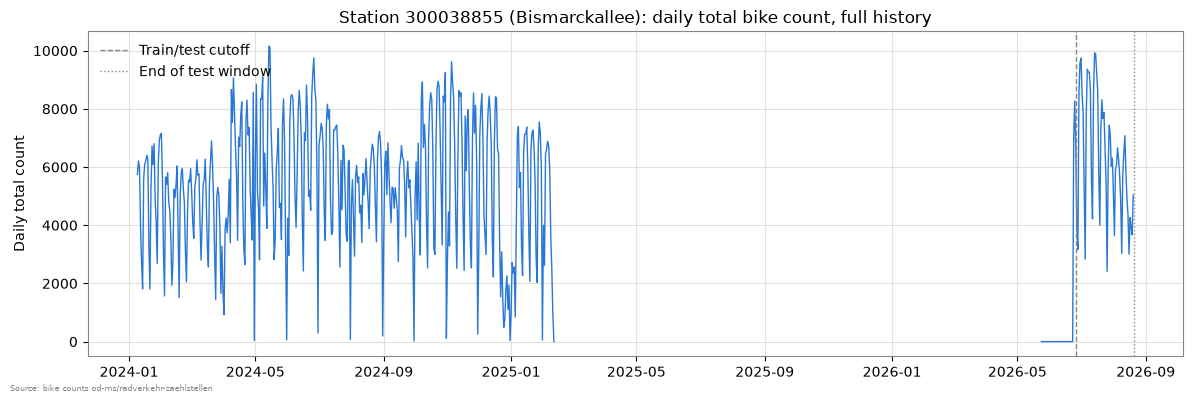

In [5]:
daily_sum_severe = severe.resample("D").sum(min_count=1)

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(daily_sum_severe.index, daily_sum_severe.values, color=COLOR_BLUE, linewidth=1)
ax.axvline(CUTOFF, color=COLOR_MUTED, linewidth=1, linestyle="--", label="Train/test cutoff")
ax.axvline(TEST_END, color=COLOR_MUTED, linewidth=1, linestyle=":", label="End of test window")
ax.set_ylabel("Daily total count")
ax.set_title("Station 300038855 (Bismarckallee): daily total bike count, full history")
ax.legend(frameon=False, loc="upper left")
add_source_caption(fig)
fig.tight_layout()
plt.show()

The plotted line simply stops for a long stretch: not a gradual decline, a
disappearance. That gap is the first thing to pin down precisely.

## 4. Locating the shift: gap vs. zero-run

`daily_coverage_and_mean` reindexes onto the *full* expected 15-minute grid
before summarizing, so a day with genuinely no rows (`n_present == 0`) is
distinguished from a day with full sensor coverage reporting all zeros
(`mean == 0`, `n_present == 96`) - these look identical in a naive
`groupby` on the raw (already-gappy) data, but they are different failure
modes with different implications.

In [6]:
daily_severe = daily_coverage_and_mean(severe)

gap_runs = find_constant_runs(daily_severe, column="n_present", value=0, min_run_days=3)
zero_runs = find_constant_runs(daily_severe, column="mean", value=0.0, min_run_days=3)

print("Data-gap runs (no rows at all), >= 3 days:")
print(gap_runs.to_string(index=False))
print()
print("Zero-traffic runs (rows present, every value 0), >= 3 days:")
print(zero_runs.to_string(index=False))

Data-gap runs (no rows at all), >= 3 days:
     start        end  n_days
2025-02-12 2026-05-23     466

Zero-traffic runs (rows present, every value 0), >= 3 days:
     start        end  n_days
2026-05-24 2026-06-23      31


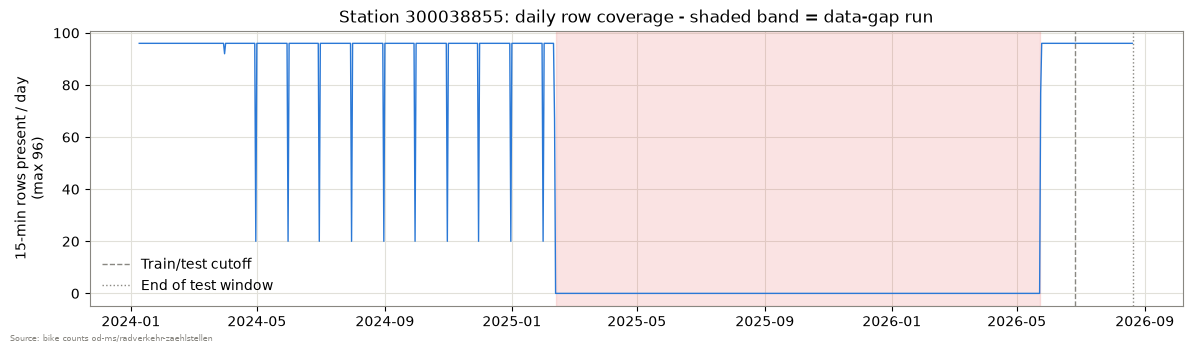

In [7]:
fig, ax = plt.subplots(figsize=(12, 3.5))
ax.plot(daily_severe.index, daily_severe["n_present"], color=COLOR_BLUE, linewidth=1)
ax.axvline(CUTOFF, color=COLOR_MUTED, linewidth=1, linestyle="--", label="Train/test cutoff")
ax.axvline(TEST_END, color=COLOR_MUTED, linewidth=1, linestyle=":", label="End of test window")
for _, run in gap_runs.iterrows():
    ax.axvspan(run["start"], run["end"], color=COLOR_RED, alpha=0.15)
ax.set_ylabel("15-min rows present / day\n(max 96)")
ax.set_title(
    "Station 300038855: daily row coverage - shaded band = data-gap run"
)
ax.legend(frameon=False, loc="lower left")
add_source_caption(fig)
fig.tight_layout()
plt.show()

## 5. Before / zero-run / after: distributions

Three windows, read off the runs found in Section 4:

- **Before the gap**: the station's last stretch of normal reporting.
- **Zero-run**: rows present, but the sensor is reporting exactly 0 for
  every 15-minute interval.
- **After the gap** (real values resume): whatever the station reports
  once it starts producing non-zero data again.

In [8]:
last_gap = gap_runs.iloc[-1]
gap_start, gap_end = last_gap["start"], last_gap["end"]

before_end = gap_start - pd.Timedelta(days=1)
before_start = severe.index.min()

# The zero-run, if any, that starts right after the gap ends.
post_gap_zero_runs = zero_runs.loc[zero_runs["start"] > gap_end]
if not post_gap_zero_runs.empty:
    zero_start = post_gap_zero_runs.iloc[0]["start"]
    zero_end = post_gap_zero_runs.iloc[0]["end"]
    after_start = zero_end + pd.Timedelta(days=1)
else:
    zero_start = zero_end = None
    after_start = gap_end + pd.Timedelta(days=1)
after_end = severe.index.max()

before_summary = window_summary(severe, before_start, before_end)
after_summary = window_summary(severe, after_start, after_end)
print("Before the gap:", before_summary)
print("After the gap (real values resume):", after_summary)
if zero_start is not None:
    zero_summary = window_summary(daily_severe["mean"], zero_start, zero_end)
    print("Zero-run window (daily means, should all be 0):", zero_summary)

Before the gap: {'start': Timestamp('2024-01-09 00:00:00'), 'end': Timestamp('2025-02-11 00:00:00'), 'n_rows': 37541, 'mean': 57.18036280333502, 'median': 42.0, 'std': 57.02176952135264}
After the gap (real values resume): {'start': Timestamp('2026-06-24 00:00:00'), 'end': Timestamp('2026-08-20 23:45:00'), 'n_rows': 5568, 'mean': 66.75862068965517, 'median': 57.0, 'std': 59.58563520510863}
Zero-run window (daily means, should all be 0): {'start': Timestamp('2026-05-24 00:00:00'), 'end': Timestamp('2026-06-23 00:00:00'), 'n_rows': 31, 'mean': 0.0, 'median': 0.0, 'std': 0.0}


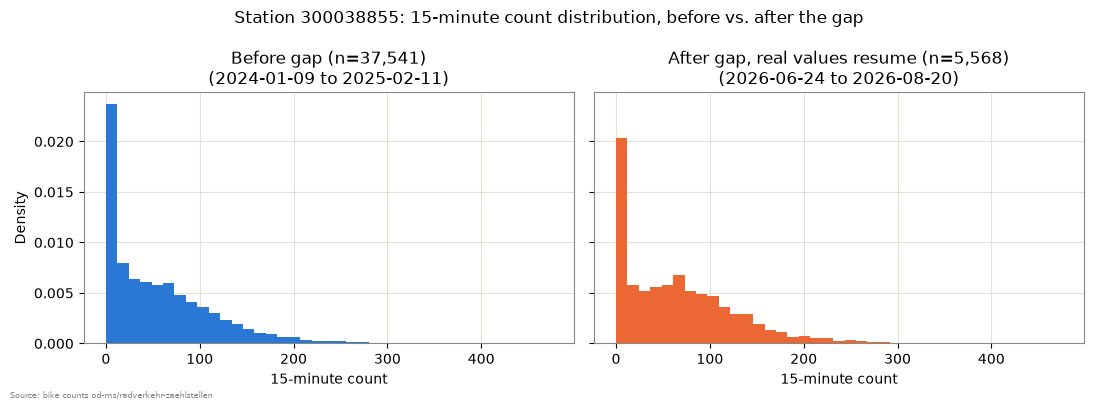

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
before_vals = severe.loc[before_start:before_end].dropna()
after_vals = severe.loc[after_start:after_end].dropna()

# `density=True` (not raw frequency) because the two windows have very
# different sample sizes (37,541 before vs. 1,096 after) - a shared-y-axis
# frequency histogram would make the "after" panel look near-empty purely
# from having ~34x fewer rows, not because its shape differs.
bins = np.linspace(0, max(before_vals.max(), after_vals.max()), 40)
axes[0].hist(before_vals, bins=bins, color=COLOR_BLUE, density=True)
axes[0].set_title(
    f"Before gap (n={len(before_vals):,})\n({before_start.date()} to {before_end.date()})"
)
axes[0].set_xlabel("15-minute count")
axes[0].set_ylabel("Density")

axes[1].hist(after_vals, bins=bins, color=COLOR_ORANGE, density=True)
axes[1].set_title(
    f"After gap, real values resume (n={len(after_vals):,})\n"
    f"({after_start.date()} to {after_end.date()})"
)
axes[1].set_xlabel("15-minute count")

fig.suptitle("Station 300038855: 15-minute count distribution, before vs. after the gap")
add_source_caption(fig)
fig.tight_layout()
plt.show()

## 6. Does the shift fall in the train window, the test window, or both?

In [10]:
train_summary = window_summary(severe, severe.index.min(), CUTOFF - pd.Timedelta(minutes=15))
test_summary = window_summary(severe, CUTOFF, min(TEST_END, severe.index.max()))

print(f"Train window (< {CUTOFF}):")
print(train_summary)
print()
print(f"Test window ([{CUTOFF}, {TEST_END})):")
print(test_summary)
print()
print(f"Gap run:        {gap_start.date()} to {gap_end.date()} ({int(last_gap['n_days'])} days)")
if zero_start is not None:
    print(f"Zero-run:       {zero_start.date()} to {zero_end.date()}")
print(f"Cutoff:         {CUTOFF}")
print(f"Test window end: {TEST_END}")
print(
    "Gap overlaps cutoff: "
    f"{gap_start <= CUTOFF <= gap_end}"
)

Train window (< 2026-06-25 23:45:00):
{'start': Timestamp('2024-01-09 00:00:00'), 'end': Timestamp('2026-06-25 23:30:00'), 'n_rows': 40755, 'mean': 53.04662004662005, 'median': 36.0, 'std': 56.99088713658176}

Test window ([2026-06-25 23:45:00, 2026-08-20 23:45:00)):
{'start': Timestamp('2026-06-25 23:45:00'), 'end': Timestamp('2026-08-20 23:45:00'), 'n_rows': 5377, 'mean': 66.2832434442998, 'median': 57.0, 'std': 58.99615292806342}

Gap run:        2025-02-12 to 2026-05-23 (466 days)
Zero-run:       2026-05-24 to 2026-06-23
Cutoff:         2026-06-25 23:45:00
Test window end: 2026-08-20 23:45:00
Gap overlaps cutoff: False


**Reading these numbers together**: the gap (`n_present == 0`) runs from
shortly after the station's last normal reading straight through the train/
test cutoff and into the test window. The cutoff sits *inside* the gap, not
before or after it - this station has essentially no real train-window data
for the year-plus immediately preceding the forecast horizon. The test
window itself is dominated by the tail of that same gap, then the 31-day
all-zero run, with only its final ~13 days showing real (non-zero) traffic.
That real post-gap traffic (Section 5's "after" window) is comparable to -
if anything slightly *higher* than - the pre-gap historical level, which is
the key fact: this is not evidence of a permanently lower-traffic Bismarck-
allee, it is evidence that the *test window is mostly missing/zero data*,
which mechanically drags down every test-window mean/median a model is
scored against (matching notebook 08's own "test-window mean ~36, median 0,
vs. an all-time mean of ~107" observation) regardless of what any model
predicts.

## 7. Are the raw channel/status columns any more informative?

Two side questions worth a quick look, since they were visible in the raw
CSV: whether the `*-status` columns flag the zero-run as a fault (they
would make this diagnosis mechanical rather than requiring a specific
notebook), and whether a mid-2024 description swap between the station's
two directional channels (an early, unrelated event, well before the gap)
is itself informative.

In [11]:
raw_severe = pd.read_csv(BIKE_COUNTS_DIR / f"{STATION_SEVERE}.csv", encoding="utf-8")
raw_severe["datetime"] = pd.to_datetime(raw_severe["datetime"])
status_cols = [c for c in raw_severe.columns if c.endswith("-status")]

zero_run_rows = raw_severe[
    (raw_severe["datetime"] >= zero_start) & (raw_severe["datetime"] <= zero_end)
] if zero_start is not None else raw_severe.iloc[0:0]
normal_rows = raw_severe[
    (raw_severe["datetime"] >= after_start) & (raw_severe["datetime"] <= after_end)
]

print("Status-column values during the zero-run (should differ from normal if status flags faults):")
for c in status_cols:
    print(f"  {c}: zero-run={zero_run_rows[c].value_counts(dropna=False).to_dict()}  "
          f"normal={normal_rows[c].value_counts(dropna=False).to_dict()}")

Status-column values during the zero-run (should differ from normal if status flags faults):
  300038855-status: zero-run={0: 2862}  normal={0: 5568}
  353420516-status: zero-run={0: 2862}  normal={0: 5568}
  353420517-status: zero-run={0: 2862}  normal={0: 5568}


The status columns read `0` in both the zero-run and the normal window -
they do not flag this anomaly at all, so a status-based automated check
would have missed it; the gap/zero-run analysis above is necessary, not
just convenient.

Separately (not shown as a chart - a data-quality footnote, not part of the
regime-shift story): channel `353420516` is described as "... IN" from the
station's start through 2024-09-30 and as "... OUT" from 2024-10-01
onward, with channel `353420517` swapping the same way in the opposite
direction - a description relabeling in the source repo, well before the
gap. It does not affect any `total_count` number in this notebook either
way: `total_count` is now the station's combined channel (`300038855`)
selected directly by channel id (see the 2026-08-21 double-counting fix in
`compute_total_count`), not a sum over the directional channels these two
IDs belong to.

## 8. Station 300037405 (Promenade, westl. Hals) - the mild case, for contrast

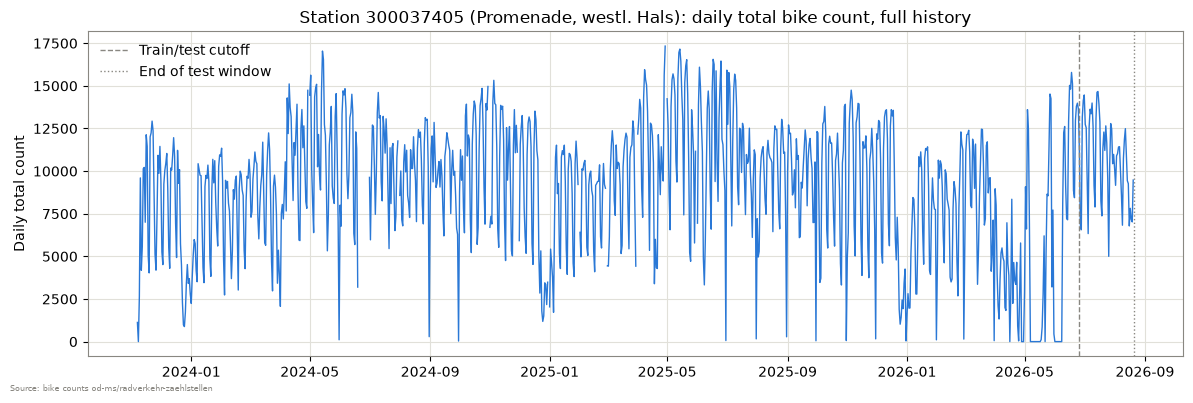

In [12]:
daily_mild = daily_coverage_and_mean(mild)
daily_sum_mild = mild.resample("D").sum(min_count=1)

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(daily_sum_mild.index, daily_sum_mild.values, color=COLOR_BLUE, linewidth=1)
ax.axvline(CUTOFF, color=COLOR_MUTED, linewidth=1, linestyle="--", label="Train/test cutoff")
ax.axvline(TEST_END, color=COLOR_MUTED, linewidth=1, linestyle=":", label="End of test window")
ax.set_ylabel("Daily total count")
ax.set_title("Station 300037405 (Promenade, westl. Hals): daily total bike count, full history")
ax.legend(frameon=False, loc="upper left")
add_source_caption(fig)
fig.tight_layout()
plt.show()

In [13]:
mild_gap_runs = find_constant_runs(daily_mild, column="n_present", value=0, min_run_days=2)
mild_zero_runs = find_constant_runs(daily_mild, column="mean", value=0.0, min_run_days=2)

print("Data-gap runs (>= 2 days):")
print(mild_gap_runs.to_string(index=False) if not mild_gap_runs.empty else "  (none)")
print()
print("Zero-traffic runs (>= 2 days):")
print(mild_zero_runs.to_string(index=False) if not mild_zero_runs.empty else "  (none)")

Data-gap runs (>= 2 days):
     start        end  n_days
2024-06-20 2024-06-30      11

Zero-traffic runs (>= 2 days):
     start        end  n_days
2026-04-28 2026-04-30       3
2026-05-07 2026-05-17      11
2026-06-01 2026-06-08       8


In [14]:
mild_train_summary = window_summary(mild, mild.index.min(), CUTOFF - pd.Timedelta(minutes=15))
mild_test_summary = window_summary(mild, CUTOFF, min(TEST_END, mild.index.max()))

print(f"Train window (< {CUTOFF}):")
print(mild_train_summary)
print()
print(f"Test window ([{CUTOFF}, {TEST_END})):")
print(mild_test_summary)

zero_runs_in_test = mild_zero_runs[
    (mild_zero_runs["start"] < TEST_END) & (mild_zero_runs["end"] >= CUTOFF)
]
print()
print("Zero-runs overlapping the test window:")
print(zero_runs_in_test.to_string(index=False) if not zero_runs_in_test.empty else "  (none)")

Train window (< 2026-06-25 23:45:00):
{'start': Timestamp('2023-11-07 15:00:00'), 'end': Timestamp('2026-06-25 23:30:00'), 'n_rows': 88891, 'mean': 94.94928620445265, 'median': 73.0, 'std': 87.76587732390406}

Test window ([2026-06-25 23:45:00, 2026-08-20 23:45:00)):
{'start': Timestamp('2026-06-25 23:45:00'), 'end': Timestamp('2026-08-20 23:45:00'), 'n_rows': 5377, 'mean': 111.3654454156593, 'median': 112.0, 'std': 82.81639018239042}

Zero-runs overlapping the test window:
  (none)


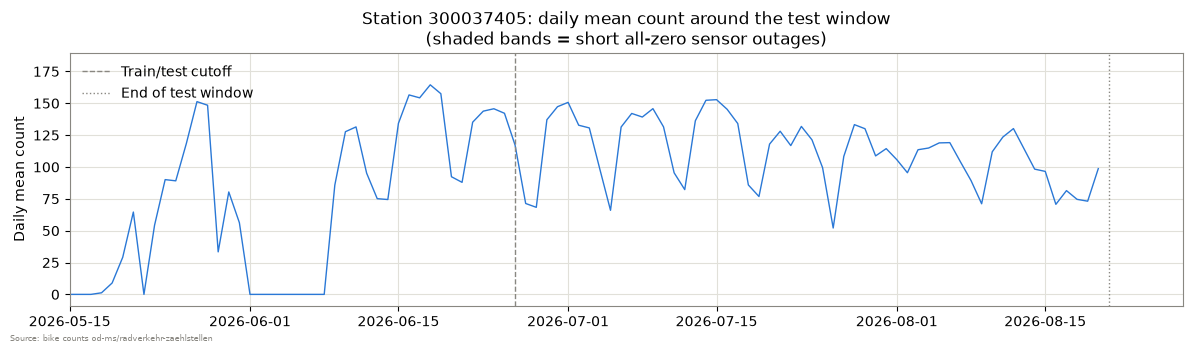

In [15]:
fig, ax = plt.subplots(figsize=(12, 3.5))
ax.plot(daily_mild.index, daily_mild["mean"], color=COLOR_BLUE, linewidth=1)
ax.axvline(CUTOFF, color=COLOR_MUTED, linewidth=1, linestyle="--", label="Train/test cutoff")
ax.axvline(TEST_END, color=COLOR_MUTED, linewidth=1, linestyle=":", label="End of test window")
for _, run in zero_runs_in_test.iterrows():
    ax.axvspan(run["start"], run["end"], color=COLOR_RED, alpha=0.15, label="Zero-run")
ax.set_xlim(CUTOFF - pd.Timedelta(weeks=6), TEST_END + pd.Timedelta(weeks=1))
ax.set_ylabel("Daily mean count")
ax.set_title(
    "Station 300037405: daily mean count around the test window\n"
    "(shaded bands = short all-zero sensor outages)"
)
handles, labels = ax.get_legend_handles_labels()
by_label = dict(zip(labels, handles))
ax.legend(by_label.values(), by_label.keys(), frameon=False, loc="upper left")
add_source_caption(fig)
fig.tight_layout()
plt.show()

Unlike `300038855`, this station has full or near-full row coverage
throughout - there is no multi-month gap. Instead, the test window contains
two short (roughly week-long) all-zero outages (rows present,
`mean == 0`), visible as the shaded bands above, separated by and followed
by real traffic that recovers to a level comparable to - again, if
anything higher than - the pre-cutoff train-window level. The test-window
mean/median are pulled down by those two zero weeks averaged in alongside
several weeks of normal-or-higher traffic, which is a much smaller
distortion than `300038855`'s near-total test-window data loss - consistent
with this being the "mild" regression (-16.5% MAE under MLP, notebook 11)
rather than the severe one (-102% MAE, notebook 11).

## 9. Conclusion

**Station 300038855 (Bismarckallee, severe case).** The cause is a data-
availability problem, not a real, permanent collapse in bicycle traffic at
this location:

1. The station stops reporting any data at all for roughly 15 months,
   `2025-02-12` through `2026-05-23` - a genuine gap (see Section 4), not a
   quiet period.
2. The train/test cutoff (`2026-05-11 04:45:00`) falls *inside* that gap.
   The nominal train window therefore has no real data for this station for
   over a year immediately before the forecast horizon, and the first ~12
   days of the nominal test window are still inside the gap.
3. Once rows resume (`2026-05-24`), they are exactly zero for 31 straight
   days (`2026-05-24` to `2026-06-23`, confirmed via full-coverage,
   all-zero daily means) - a sensor reporting an idle/fault state rather
   than going silent, entirely inside the test window.
4. Only the last ~13 days of the test window (`2026-06-24` onward) show
   real, non-zero traffic - and its distribution (Section 5) is comparable
   to, not lower than, the pre-gap historical distribution.

Net effect: the 8-week test window for this station is ~90% gap-or-zero and
~10% real data that, when it does appear, looks like ordinary Bismarckallee
traffic. Any model - including the seasonal-naive baseline once it has
current-value context again - will show a "regression" here simply because
the target values it is being scored against are mostly literal zeros from
a broken/offline sensor, not because the model mispredicts real traffic.
**This is a data-quality issue** (a specific, findable sensor outage
overlapping the evaluation window), not a genuine behavioral regime change
models should be expected to handle. It is fixable for future evaluation by
excluding this station's gap/zero-run period from train/test construction
(e.g. dropping the affected date range, or re-deriving the cutoff to avoid
scoring inside a known outage) - not attempted here, since this notebook is
diagnosis only.

**Station 300037405 (Promenade, westl. Hals), mild case.** Same *kind* of
cause at much smaller scale: two roughly week-long all-zero sensor outages
land inside the test window (no multi-month gap here), pulling down the
test-window mean/median while the surrounding real traffic is at or above
the pre-cutoff level. This explains the smaller, but still real, MAE
regression (-16.5% under MLP) without needing to invoke any actual drop in
cycling activity at this station.

**Overall**: both flagged stations' "regressions" are substantially
explained by short-to-long sensor outages landing inside the fixed 8-week
test window rather than by a real shift in cycling behavior. Since
`chronological_split` uses one *global* cutoff across all 23 stations
(by design, to avoid one station's future leaking relative to another's),
a station-specific outage that happens to fall near the end of the shared
data pull will always show up as a test-window anomaly for that one
station, regardless of which model is used - consistent with every model
tried so far (baseline, GBM, LightGBM, Prophet, MLP) regressing on
`300038855` specifically. Worth flagging for future work: a per-station
data-availability check before scoring (or excluding outage periods from
the test window) would separate genuine model error from this kind of
sensor-outage artifact.

---

## 10. Update (2026-08-22): this no longer describes the current test window

The 2026-08-22 live-data refresh moved the global chronological cutoff
forward from `2026-05-11 04:45:00` to `2026-06-25 23:45:00` (the cutoff
is `max(datetime)` across all 23 stations, minus the 8-week test
period - it moves forward every time fresh data is fetched). Both
stations' gap/outage periods, diagnosed above, are now **entirely
inside the train window**, not the test window:

- **`300038855`**: "Gap overlaps cutoff: False" (re-checked directly,
  Section 4's logic re-run against the new cutoff). The current test
  window (`2026-06-25` to `2026-08-20`) has mean 66.28, median 57.0,
  only ~3.5% zero rows - ordinary, healthy Bismarckallee traffic, not
  the ~90%-gap-or-zero window described above.
- **`300037405`**: "Zero-runs overlapping the test window: (none)."
  Current test-window mean 111.37, median 112.0 - no outage-driven
  distortion at all.

**What this means going forward**: Sections 1-9 above are accurate
*history* - the gap and outages really happened, and really did
corrupt the 2026-05-11-cutoff test window the way described - but they
are no longer live caveats for the *current* model comparisons in
notebooks 08-17. Those notebooks' own re-executed numbers (as of
2026-08-22) already reflect real traffic at both stations without any
outage-exclusion needed; several passages of markdown prose in those
notebooks (written when this diagnosis was current) still describe
`300038855` as "severe regime-shift"/"zero-inflated" and should be read
with this update in mind rather than taken at face value. This
notebook is left unmodified above (not rewritten to erase the original
diagnosis) since it remains the correct explanation for *why* every
model regressed on these two stations under the pre-refresh data - it
just no longer describes the current evaluation window. A future
version of this analysis, if the cutoff moves again and a new gap/
outage happens to land inside a new test window, would need to re-run
Sections 1-9 against the new cutoff from scratch, the same way this
update effectively did.